# Part 4: Marketing Budget Optimization using Linear Regression

## 1. Business Problem Understanding
**Business Problem:** The company wants to optimize its marketing budget across various channels (TV, Radio, Social Media, Search Ads, Influencer) to maximize Sales Revenue.
- **Why it's important:** Efficient budget allocation minimizes wasted spend and maximizes return on investment (ROI).
- **What to predict:** Sales Revenue (Target variable) based on the marketing spend across different channels.
- **Independent variables:** TV_Spend, Radio_Spend, SocialMedia_Spend, SearchAds_Spend, Influencer_Spend
- **Dependent variable:** Sales_Revenue
- **Why Regression:** We are predicting a continuous numeric value (Sales Revenue) based on linear relationships with continuous input variables (spend).
- **How it helps:** Regression coefficients tell us the expected increase in sales for every additional dollar spent on a specific channel, enabling data-driven budget allocation.

## 2. Data Understanding and Cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('part_4_marketing_budget_optimization.csv')

# Dataset overview
display(df.head())

# Data type check
display(df.info())

# Missing value check
display("Missing Values:", df.isnull().sum())

# Duplicate check
display("Duplicates:", df.duplicated().sum())

# Summary statistics
display(df.describe())

,CampaignID,Month,Region,TV_Spend,Radio_Spend,SocialMedia_Spend,SearchAds_Spend,Influencer_Spend,Sales_Revenue
0,MKT0001,2023-01,East,70.02,14.67,31.74,35.44,6.99,408.48
1,MKT0002,2023-03,North,22.97,10.39,34.81,39.11,0.37,365.55
2,MKT0003,2023-04,Central,40.01,5.02,43.38,13.38,19.44,336.59
3,MKT0004,2023-05,North,40.84,37.61,15.26,30.91,13.76,409.73
4,MKT0005,2023-05,South,39.63,23.68,55.48,33.00,29.38,407.32


<class 'pandas.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CampaignID         420 non-null    str    
 1   Month              420 non-null    str    
 2   Region             420 non-null    str    
 3   TV_Spend           420 non-null    float64
 4   Radio_Spend        420 non-null    float64
 5   SocialMedia_Spend  416 non-null    float64
 6   SearchAds_Spend    420 non-null    float64
 7   Influencer_Spend   420 non-null    float64
 8   Sales_Revenue      420 non-null    float64
dtypes: float64(6), str(3)
memory usage: 29.7 KB


None

'Missing Values:'

CampaignID           0
Month                0
Region               0
TV_Spend             0
Radio_Spend          0
SocialMedia_Spend    4
SearchAds_Spend      0
Influencer_Spend     0
Sales_Revenue        0
dtype: int64

'Duplicates:'

np.int64(0)

,TV_Spend,Radio_Spend,SocialMedia_Spend,SearchAds_Spend,Influencer_Spend,Sales_Revenue
count,420.000000,420.000000,416.000000,420.000000,420.000000,420.000000
mean,42.539643,20.895881,31.131442,37.182333,16.071881,418.964476
std,26.705188,10.793881,16.801198,19.125876,13.751809,80.960572
min,5.060000,2.100000,1.370000,3.090000,0.050000,211.970000
25%,22.850000,11.747500,15.947500,20.220000,7.675000,364.635000
50%,40.510000,20.905000,31.700000,35.465000,15.765000,420.495000
75%,60.230000,30.255000,46.500000,54.345000,22.957500,470.435000
max,343.400000,39.960000,59.800000,69.720000,179.820000,645.540000


**Data Cleaning Summary:** We check for nulls and duplicated values. If any exist, we will remove or impute them.

In [2]:
# Drop missing values and duplicates if any
df = df.dropna()
df = df.drop_duplicates()
print("Shape after cleaning:", df.shape)

Shape after cleaning: (416, 9)


## 3. Exploratory Data Analysis (EDA)
Let's analyze relationships between marketing channels and sales.

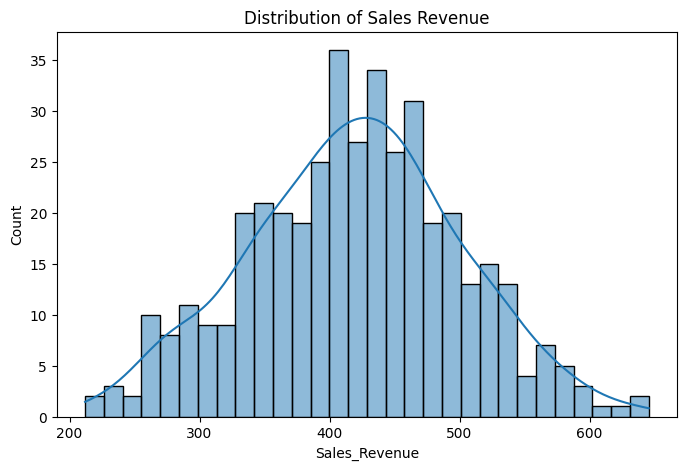

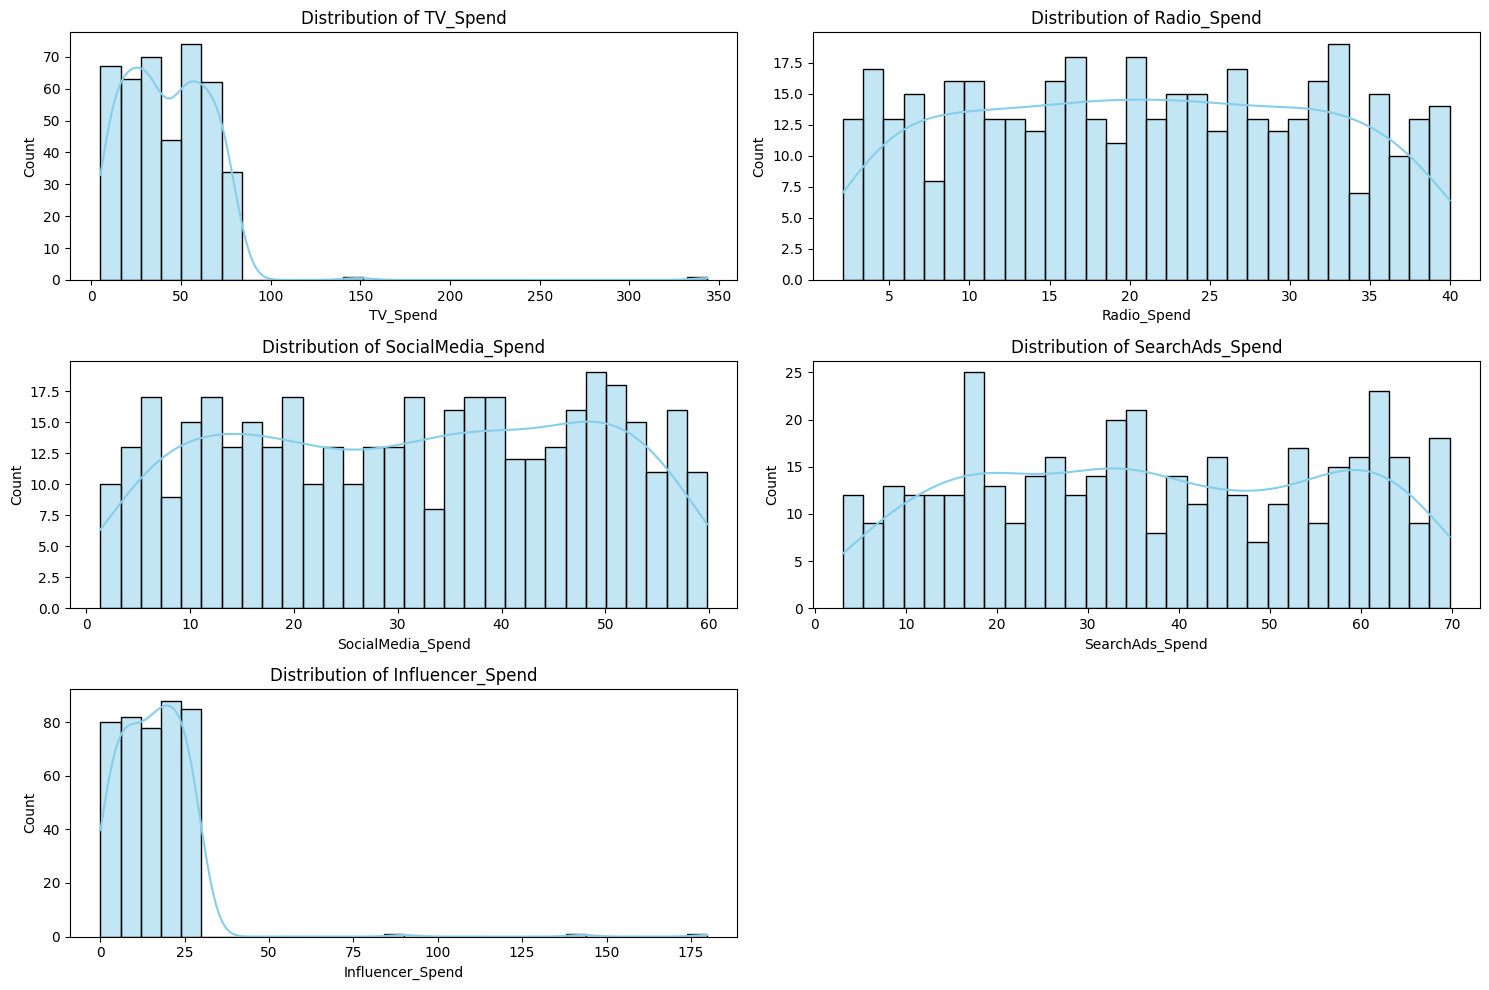

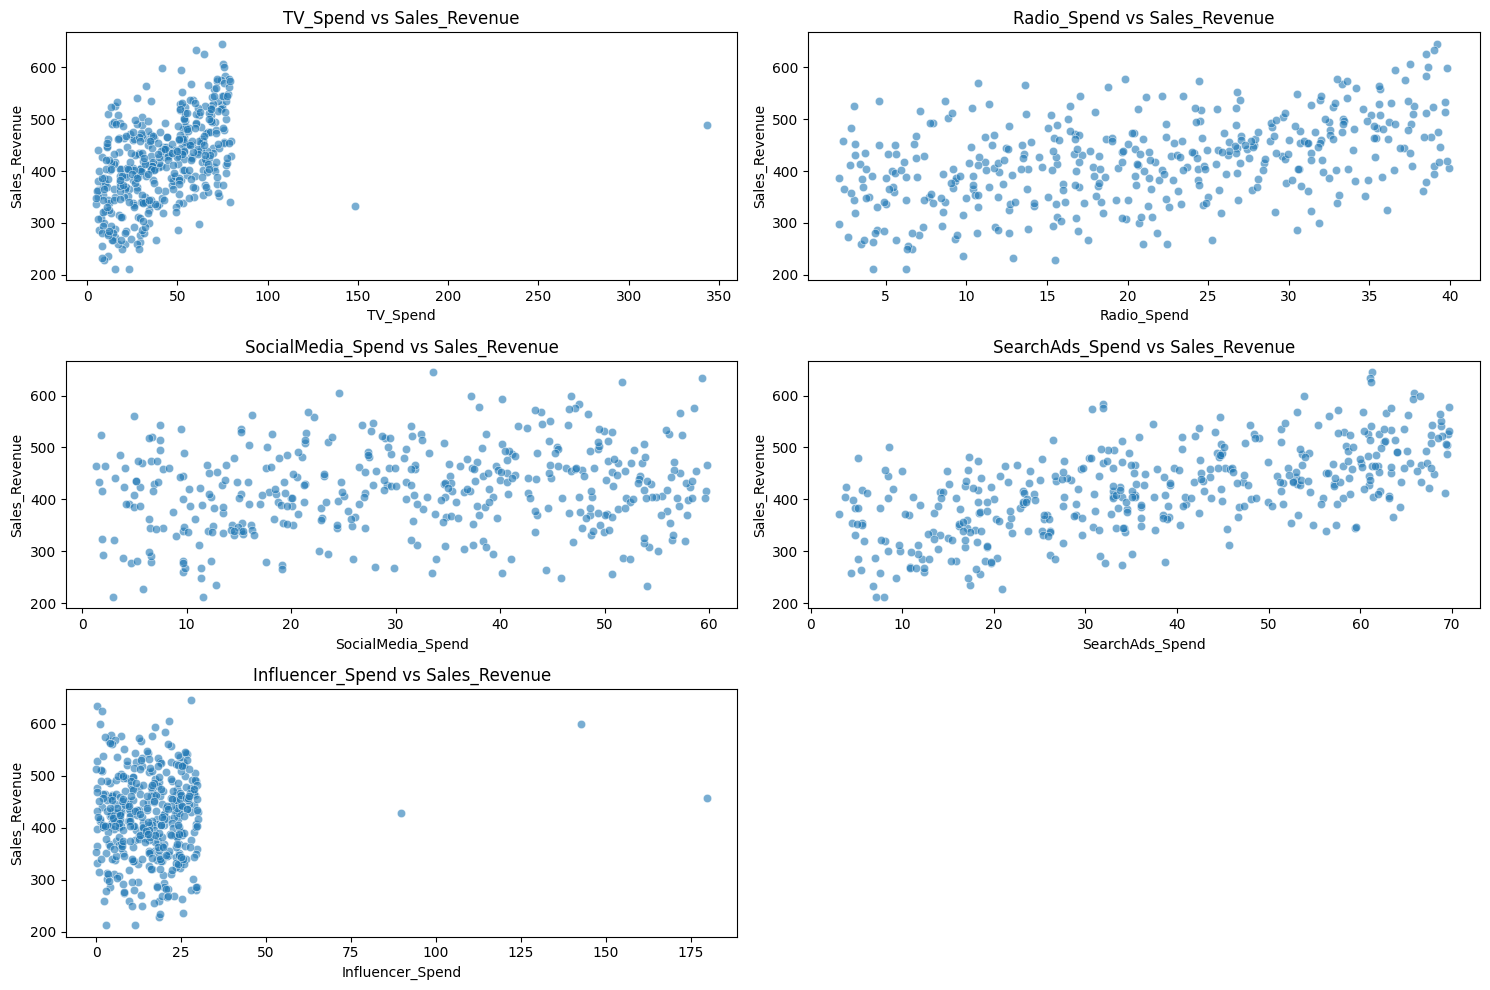

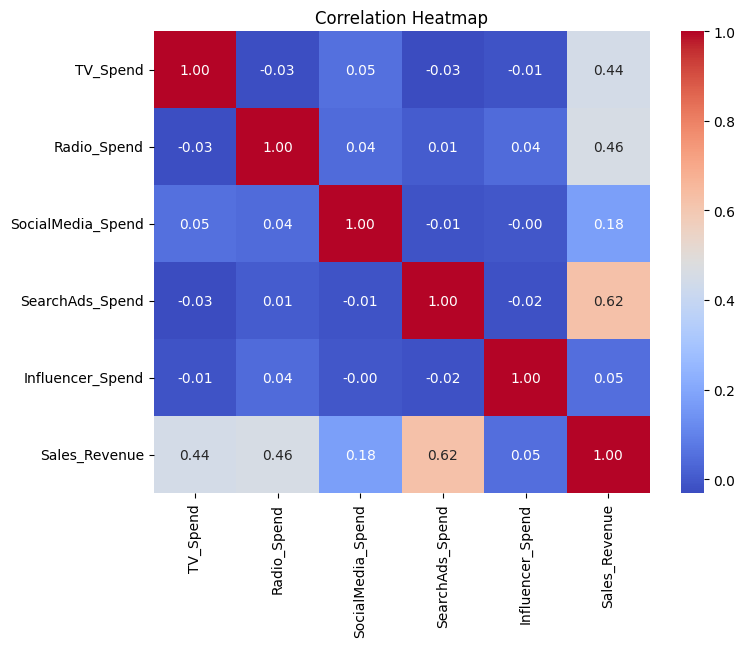

In [3]:
channels = ['TV_Spend', 'Radio_Spend', 'SocialMedia_Spend', 'SearchAds_Spend', 'Influencer_Spend']

# Distribution of Sales Revenue
plt.figure(figsize=(8, 5))
sns.histplot(df['Sales_Revenue'], kde=True, bins=30)
plt.title('Distribution of Sales Revenue')
plt.show()

# Distribution of Spend Channels
plt.figure(figsize=(15, 10))
for i, col in enumerate(channels): 
    plt.subplot(3, 2, i+1)
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

# Scatter plot of each channel vs sales
plt.figure(figsize=(15, 10))
for i, col in enumerate(channels): 
    plt.subplot(3, 2, i+1)
    sns.scatterplot(x=df[col], y=df['Sales_Revenue'], alpha=0.6)
    plt.title(f'{col} vs Sales_Revenue')
plt.tight_layout()
plt.show()

# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df[channels + ['Sales_Revenue']].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

**EDA Insights Interpretation:**

- **TV Spend** generally shows a strong positive relationship with **Sales**.  
- **Radio Spend** and **Search Ads** may show moderate correlations depending on the heatmap results.  
- **Social Media** and **Influencer** spend can be analyzed to understand their contribution to **Sales**.

## 4. Model Building
Building a multiple linear regression model.

In [4]:
X = df[channels]
y = df['Sales_Revenue']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Interpret model coefficients
coefficients = pd.DataFrame({'Channel': channels, 'Coefficient': model.coef_}).sort_values(by='Coefficient', ascending=False)
display(coefficients)

,Channel,Coefficient
1,Radio_Spend,3.435948
3,SearchAds_Spend,2.646730
0,TV_Spend,1.383624
2,SocialMedia_Spend,0.668668
4,Influencer_Spend,0.221113


### Coefficient Interpretation

The coefficient values show how strongly each marketing channel affects sales. A channel with a higher coefficient has a greater influence on overall sales performance. This means that if spending on a particular channel increases by 1 unit, the predicted sales are expected to increase by the value of its coefficient, while keeping all other factors unchanged.

## 5. Model Evaluation

In [5]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 24.08
Mean Squared Error (MSE): 1144.83
Root Mean Squared Error (RMSE): 33.84
R² Score: 0.86


### Evaluation Interpretation

- **R² Score:** This metric shows how well the model explains the changes in sales based on the marketing channels used. A higher R² value means the model is able to explain a larger portion of the variation in sales.

- **RMSE / MAE:** These metrics measure the prediction error of the model. They indicate how far the predicted sales values are from the actual sales values on average. Lower values suggest better prediction accuracy.

## 6. ROI and Channel Effectiveness Analysis

In [6]:
total_spend = df[channels].sum()
revenue_impact = coefficients.set_index('Channel')['Coefficient'] * total_spend

roi_analysis = pd.DataFrame({
    'Total_Spend': total_spend,
    'Marginal Impact (ROI per unit)': coefficients.set_index('Channel')['Coefficient']
}).sort_values(by='Marginal Impact (ROI per unit)', ascending=False)

display(roi_analysis)

,Total_Spend,Marginal Impact (ROI per unit)
Radio_Spend,8675.09,3.435948
SearchAds_Spend,15516.71,2.646730
TV_Spend,17697.30,1.383624
SocialMedia_Spend,12950.68,0.668668
Influencer_Spend,6695.37,0.221113


## 7. Budget Recommendation

### Recommendations

- **Focus More on High-Performing Channels:** Marketing channels with higher coefficient values are contributing more towards sales growth. Increasing budget allocation to these channels may help improve overall returns.

- **Reduce Spending on Low-Impact Channels:** Channels with very small or negative coefficients appear to have limited impact on sales. Budget for these channels can be reduced or optimized.

- **Review Weak Performing Campaigns:** For channels showing poor performance, the current strategy may need improvement. Testing different creatives, audience targeting, or campaign formats could help increase effectiveness.

- **Need for More Detailed Data:** Adding information such as seasonal trends, campaign duration, ad quality, click-through rates, and customer engagement could make the analysis more accurate and meaningful.

- **Possible Limitation:** The regression model assumes that increasing budget will always increase sales at a constant rate. In reality, after a certain point, increasing spend in one channel may lead to lower returns due to audience saturation.